# UTS: Klasifikasi Teks Berita Menggunakan Word Embedding Skip-gram dan Naive Bayes

Notebook ini mengimplementasikan pipeline klasifikasi teks berita dari dataset mentah (3 kolom: `ID`, `Isi berita`, `label`) hingga evaluasi model.

**Ringkasan Alur Kerja:**
1. **Dataset**: 200 artikel berita mentah dari Detik.com (100 *Sport*, 100 *Finance*).
2. **Pra-pemrosesan**: Pembersihan karakter non-alfabet, tokenisasi, dan penghapusan stopwords.
3. **Split Data**: 80% data latih (160 dokumen), 20% data uji (40 dokumen) dengan *stratified sampling*.
4. **Word Embedding**: Arsitektur **Skip-gram** (`sg=1`) menggunakan **Gensim Word2Vec**.
5. **Representasi Dokumen**: *Average Pooling (Mean Word Vector)* dari seluruh kata per dokumen.
6. **Model Klasifikasi**: **Naive Bayes**.
7. **Evaluasi**: Akurasi, Precision, Recall, F1-Score, dan Confusion Matrix.

---

## 1. Import Library & Pemuatan Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

# Pustaka Gensim Word2Vec (Skip-gram)
from gensim.models import Word2Vec

# Modul Stopwords Bahasa Indonesia (Sastrawi)
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Modul Machine Learning Klasifikasi & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set seed agar hasil eksperimen konsisten (reproducible)
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Seluruh pustaka pendukung berhasil dimuat!")

Seluruh pustaka pendukung berhasil dimuat!


## 2. Konfigurasi Parameter & Pemuatan Dataset Berita Mentah

Dataset terdiri dari **200 artikel berita** hasil crawling Detik.com dengan **3 kolom**:
- `ID`: Nomor identitas berita.
- `Isi berita`: Teks mentah artikel berita.
- `label`: Kategori berita (*Sport* atau *Finance*).

Distribusi kelas seimbang: 100 berita Sport dan 100 berita Finance.

In [2]:
# =============================================================================
# PARAMETER EKSPERIMEN
# =============================================================================
VECTOR_SIZE  = 100       # Dimensi vektor embedding kata (N)
WINDOW_SIZE  = 5         # Ukuran jendela konteks Skip-gram (C)
MIN_COUNT    = 2         # Frekuensi minimum kata untuk masuk kosakata
EPOCHS       = 35        # Jumlah iterasi pelatihan Word2Vec
TEST_SIZE    = 0.20      # Proporsi data uji: 20%
RANDOM_STATE = 42        # Seed untuk reprodusibilitas
# =============================================================================

# Membaca dataset 200 berita mentah Detik.com (3 kolom)
csv_path = "dataset_berita_detik.csv"
df = pd.read_csv(csv_path)

print(f"Bentuk Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Kolom Dataset: {df.columns.tolist()}")
print(f"\nDistribusi Label Berita:")
print(df['label'].value_counts())
print(f"\nContoh 5 Sampel Data Teratas:")
display(df.head(5))

Bentuk Dataset: 200 baris, 3 kolom
Kolom Dataset: ['ID', 'Isi berita', 'label']

Distribusi Label Berita:
label
Sport      100
Finance    100
Name: count, dtype: int64

Contoh 5 Sampel Data Teratas:


,ID,Isi berita,label
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,Sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",Sport
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,Sport
3,4,Dua petenis Indonesia menyusul Nathan Barki lo...,Sport
4,5,Babak utama Seri IV M-15 Men's World Tennis Ch...,Sport


## 3. Pra-pemrosesan Teks

Tahapan pra-pemrosesan bertahap:
1. **Pembersihan karakter non-alfabet**: Menghapus tanda baca, angka, dan karakter khusus menggunakan regex `[^a-zA-Z\s]`.
2. **Case folding**: Mengubah seluruh huruf menjadi huruf kecil (*lowercase*).
3. **Tokenisasi**: Memecah teks menjadi daftar kata/token.
4. **Stopword removal**: Menghapus kata-kata fungsional/sambung menggunakan kamus **Sastrawi**.

In [3]:
# Inisialisasi kamus stopwords Sastrawi
factory = StopWordRemoverFactory()
stopword_set = set(factory.get_stop_words())
print(f"Jumlah kata stopword Sastrawi: {len(stopword_set)} kata")

# 1. Pembersihan karakter non-alfabet
df['teks_bersih'] = df['Isi berita'].apply(
    lambda text: re.sub(r'[^a-zA-Z\s]', ' ', str(text)).strip()
)

# 2. Case folding (lowercase)
df['teks_bersih'] = df['teks_bersih'].str.lower()

# 3. Tokenisasi
df['tokens'] = df['teks_bersih'].apply(lambda text: text.split())

# 4. Penghapusan stopwords (Sastrawi)
df['tokens_clean'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stopword_set and len(w) > 1]
)

# Statistik sebelum dan sesudah stopword removal
total_before = sum(len(t) for t in df['tokens'])
total_after  = sum(len(t) for t in df['tokens_clean'])
vocab_before = len(set(w for t in df['tokens'] for w in t))
vocab_after  = len(set(w for t in df['tokens_clean'] for w in t))

print(f"\n=== STATISTIK PRA-PEMROSESAN ===")
print(f"Total token sebelum stopword removal : {total_before}")
print(f"Total token setelah stopword removal  : {total_after}")
print(f"Token tereliminasi                    : {total_before - total_after} ({(total_before - total_after) / total_before * 100:.1f}%)")
print(f"Kosakata unik sebelum                 : {vocab_before}")
print(f"Kosakata unik setelah                 : {vocab_after}")
print(f"Rata-rata kata per dokumen (setelah)   : {total_after / len(df):.1f}")

print(f"\nContoh hasil pra-pemrosesan (dokumen pertama):")
print(f"  Teks asli    : {df['Isi berita'].iloc[0][:120]}...")
print(f"  Teks bersih  : {df['teks_bersih'].iloc[0][:120]}...")
print(f"  Tokens (10)  : {df['tokens_clean'].iloc[0][:10]}")

Jumlah kata stopword Sastrawi: 123 kata

=== STATISTIK PRA-PEMROSESAN ===
Total token sebelum stopword removal : 60051
Total token setelah stopword removal  : 45609
Token tereliminasi                    : 14442 (24.0%)
Kosakata unik sebelum                 : 6344
Kosakata unik setelah                 : 6214
Rata-rata kata per dokumen (setelah)   : 228.0

Contoh hasil pra-pemrosesan (dokumen pertama):
  Teks asli    : Persatuan Bulutangkis Indonesia (PBSI) baru saja mengumumkan daftar 20 pemain yang dibawa ke Asian Games 2026. Jonatan C...
  Teks bersih  : persatuan bulutangkis indonesia  pbsi  baru saja mengumumkan daftar    pemain yang dibawa ke asian games       jonatan c...
  Tokens (10)  : ['persatuan', 'bulutangkis', 'indonesia', 'pbsi', 'baru', 'mengumumkan', 'daftar', 'pemain', 'dibawa', 'asian']


## 4. Pembagian Dataset: 80% Data Latih & 20% Data Uji (Stratified Split)

Dataset dibagi secara **stratified** untuk mempertahankan proporsi kelas:
- **Data Latih (Training)**: 80% = **160 dokumen** (80 Sport + 80 Finance).
- **Data Uji (Testing)**: 20% = **40 dokumen** (20 Sport + 20 Finance).

In [4]:
# Pembagian indeks data latih (80%) dan data uji (20%) secara stratified
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['label']
)

# Menandai split pada DataFrame
df['Split'] = 'Train'
df.loc[test_idx, 'Split'] = 'Test'

# Tabel distribusi split
df_split = pd.crosstab(df['Split'], df['label'], margins=True, margins_name='Total')
df_split['Proporsi'] = [
    f"{len(test_idx) / len(df) * 100:.0f}%",
    f"{len(train_idx) / len(df) * 100:.0f}%",
    "100%"
]

print("=== DISTRIBUSI PEMBAGIAN DATASET (STRATIFIED SPLIT 80:20) ===")
display(df_split)

# Membuat korpus latih dan uji
corpus_train = df.loc[train_idx, 'tokens_clean'].tolist()
corpus_test  = df.loc[test_idx, 'tokens_clean'].tolist()
corpus_all   = df['tokens_clean'].tolist()

y_train = df.loc[train_idx, 'label'].values
y_test  = df.loc[test_idx, 'label'].values

print(f"\nJumlah dokumen latih : {len(train_idx)}")
print(f"Jumlah dokumen uji   : {len(test_idx)}")

=== DISTRIBUSI PEMBAGIAN DATASET (STRATIFIED SPLIT 80:20) ===


label,Finance,Sport,Total,Proporsi
Split,,,,
Test,20,20,40,20%
Train,80,80,160,80%
Total,100,100,200,100%



Jumlah dokumen latih : 160
Jumlah dokumen uji   : 40


## 5. Word Embedding: Pelatihan Model Skip-gram (Gensim Word2Vec)

### Arsitektur Skip-gram
Arsitektur **Skip-gram** memprediksi kata-kata konteks $w_{t+j}$ di sekitar kata target $w_t$ dalam radius jendela $C$. Fungsi objektif:

$$\mathcal{L}(\theta) = \sum_{t=1}^{T} \sum_{-C \le j \le C, j \neq 0} \log P(w_{t+j} \mid w_t)$$

### Representasi Vektor Dokumen (Average Pooling)
Setiap dokumen direpresentasikan sebagai rata-rata vektor dari seluruh kata penyusunnya:

$$\mathbf{v}_{\text{dokumen}} = \frac{1}{|D|} \sum_{w \in D, w \in \text{Vocab}} \mathbf{v}_w$$

Model Word2Vec dilatih pada **seluruh korpus** (200 dokumen) agar kosakata yang dipelajari mencakup semua kata, namun evaluasi klasifikasi hanya dilakukan pada data uji.

In [ ]:
def train_skipgram(corpus, vector_size=100, window=5, min_count=2, epochs=35, seed=42):
    """
    Melatih model Word2Vec Skip-gram menggunakan library Gensim.
    Parameter sg=1 menandakan arsitektur Skip-gram.
    workers=1 dipadukan dengan seed konstan memastikan hasil deterministik.
    """
    model = Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,
        epochs=epochs,
        seed=seed,
        workers=1
    )
    return model


def get_document_vectors(corpus, model, vector_size=100):
    """
    Menghasilkan representasi vektor dokumen berdimensi N
    menggunakan Average (Mean) Pooling dari kata-kata penyusun dokumen.
    """
    doc_vectors = []
    for doc in corpus:
        word_vecs = [model.wv[w] for w in doc if w in model.wv]
        if len(word_vecs) == 0:
            doc_vectors.append(np.zeros(vector_size))
        else:
            doc_vectors.append(np.mean(word_vecs, axis=0))
    return np.array(doc_vectors)


print("Fungsi pelatihan Skip-gram dan Mean Pooling siap digunakan!")

Fungsi pelatihan Skip-gram dan Mean Pooling siap digunakan!


In [6]:
t_start = time.time()

# 1. Pelatihan Model Word2Vec Skip-gram pada seluruh korpus
model_sg = train_skipgram(
    corpus=corpus_all,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)

t_w2v = time.time() - t_start

print(f"Model Skip-gram berhasil dilatih dalam {t_w2v:.2f} detik!")
print(f"Jumlah Kosakata Model (Vocabulary Size) : {len(model_sg.wv)} kata unik")
print(f"Dimensi Vektor Embedding per Kata       : {model_sg.wv.vector_size}")

# 2. Ekstraksi Vektor Dokumen (Mean Pooling)
X_train = get_document_vectors(corpus_train, model_sg, vector_size=VECTOR_SIZE)
X_test  = get_document_vectors(corpus_test, model_sg, vector_size=VECTOR_SIZE)

print(f"\nBentuk Matriks Fitur Data Latih : {X_train.shape} ({X_train.shape[0]} dokumen x {X_train.shape[1]} dimensi)")
print(f"Bentuk Matriks Fitur Data Uji   : {X_test.shape} ({X_test.shape[0]} dokumen x {X_test.shape[1]} dimensi)")

Model Skip-gram berhasil dilatih dalam 9.24 detik!
Jumlah Kosakata Model (Vocabulary Size) : 3789 kata unik
Dimensi Vektor Embedding per Kata       : 100

Bentuk Matriks Fitur Data Latih : (160, 100) (160 dokumen x 100 dimensi)
Bentuk Matriks Fitur Data Uji   : (40, 100) (40 dokumen x 100 dimensi)


### Contoh Vektor Embedding Kata

Menampilkan vektor embedding dari beberapa kata sampel hasil pelatihan Skip-gram.

In [7]:
# Tampilkan contoh vektor embedding untuk beberapa kata sampel
sample_words = ['indonesia', 'pertandingan', 'ekonomi', 'saham', 'gol', 'rupiah', 'pemain', 'bank', 'juara']
sample_words_in_vocab = [w for w in sample_words if w in model_sg.wv]

if sample_words_in_vocab:
    df_vectors = pd.DataFrame(
        [model_sg.wv[w] for w in sample_words_in_vocab],
        index=sample_words_in_vocab,
        columns=[f'dim_{i+1}' for i in range(VECTOR_SIZE)]
    )
    print(f"=== CONTOH VEKTOR EMBEDDING SKIP-GRAM ({len(sample_words_in_vocab)} kata x {VECTOR_SIZE} dimensi) ===")
    display(df_vectors.iloc[:, :10])  # Tampilkan 10 dimensi pertama saja
else:
    print("Kata sampel tidak ditemukan dalam kosakata model.")

# Kata-kata paling mirip dengan 'indonesia' (jika ada)
if 'indonesia' in model_sg.wv:
    print(f"\n=== 10 KATA PALING MIRIP DENGAN 'indonesia' ===")
    for word, sim in model_sg.wv.most_similar('indonesia', topn=10):
        print(f"  {word:<20s} → similarity = {sim:.4f}")

=== CONTOH VEKTOR EMBEDDING SKIP-GRAM (8 kata x 100 dimensi) ===


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
indonesia,0.221172,-0.260316,-0.430994,-0.219952,0.241814,0.128637,-0.239875,0.618024,-0.335375,-0.286126
pertandingan,0.420200,-1.035386,0.588147,-0.848175,-0.679445,0.548863,0.211394,0.135329,0.551419,-0.304934
ekonomi,0.262713,-0.825107,0.757406,-0.741264,-0.250109,-0.211492,-0.281774,-0.087914,0.401507,0.065473
saham,0.374709,-0.946768,-0.075328,0.338076,-0.181991,0.383201,0.001779,-0.694090,-0.294026,-0.413647
rupiah,-0.413699,-0.409701,0.264198,-0.166696,0.073630,0.430211,0.433326,-0.111142,0.196700,-0.234333
pemain,0.529407,-0.302780,1.179802,-0.248399,0.385004,-0.978953,0.163625,0.387026,-0.565372,-0.611075
bank,0.706236,0.179805,-0.656316,-0.873189,-0.774576,-0.174929,-0.528809,-0.307084,-0.594701,-0.468941
juara,-0.162868,-0.905876,0.435530,-0.007889,-0.350083,0.059471,-0.216967,0.603276,0.023113,-0.189195



=== 10 KATA PALING MIRIP DENGAN 'indonesia' ===
  menindaklanjuti      → similarity = 0.3834
  aluminium            → similarity = 0.3726
  membentuk            → similarity = 0.3607
  misi                 → similarity = 0.3597
  penduduk             → similarity = 0.3590
  saing                → similarity = 0.3589
  lembaga              → similarity = 0.3586
  rusal                → similarity = 0.3586
  membesut             → similarity = 0.3579
  gaido                → similarity = 0.3569


## 6. Klasifikasi Menggunakan Gaussian Naive Bayes

**Gaussian Naive Bayes** mengasumsikan fitur kontinu (vektor embedding) berdistribusi Gaussian/Normal pada setiap kelas. Probabilitas posterior dihitung berdasarkan teorema Bayes:

$$P(C_k \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C_k) \, P(C_k)}{P(\mathbf{x})}$$

dengan asumsi independensi antar-fitur (*naive assumption*):

$$P(\mathbf{x} \mid C_k) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi \sigma_{ki}^2}} \exp\left(-\frac{(x_i - \mu_{ki})^2}{2\sigma_{ki}^2}\right)$$

In [ ]:
# Pelatihan dan Prediksi Gaussian Naive Bayes
t_nb_start = time.time()

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

t_nb = time.time() - t_nb_start

# Metrik Evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='Sport')
rec  = recall_score(y_test, y_pred, pos_label='Sport')
f1   = f1_score(y_test, y_pred, pos_label='Sport')

print("=" * 60)
print("  HASIL EVALUASI: Gaussian Naive Bayes + Skip-gram")
print("=" * 60)
print(f"  Akurasi    : {acc:.4f} ({acc * 100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  Waktu      : {t_nb:.4f} detik")
print("=" * 60)

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Finance', 'Sport']))

  HASIL EVALUASI: Gaussian Naive Bayes + Skip-gram
  Akurasi    : 0.9750 (97.50%)
  Precision  : 1.0000
  Recall     : 0.9500
  F1-Score   : 0.9744
  Waktu      : 0.0061 detik

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Finance       0.95      1.00      0.98        20
       Sport       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



## 7. Tabel Detail Prediksi Data Uji

In [9]:
# Tabel detail prediksi vs aktual pada data uji
df_result = df.loc[test_idx, ['ID', 'Isi berita', 'label']].copy()
df_result['Prediksi'] = y_pred
df_result['Status'] = np.where(df_result['label'] == df_result['Prediksi'], '✓ Benar', '✗ Salah')
df_result['Isi berita'] = df_result['Isi berita'].str[:80] + '...'

print(f"=== TABEL PREDIKSI DATA UJI ({len(test_idx)} dokumen) ===")
display(df_result[['ID', 'Isi berita', 'label', 'Prediksi', 'Status']])

# Hitung jumlah benar dan salah
n_correct = (df_result['label'] == df_result['Prediksi']).sum()
n_wrong   = (df_result['label'] != df_result['Prediksi']).sum()
print(f"\nBenar: {n_correct}/{len(test_idx)}, Salah: {n_wrong}/{len(test_idx)}")

=== TABEL PREDIKSI DATA UJI (40 dokumen) ===


,ID,Isi berita,label,Prediksi,Status
137,138,PT Danantara Investment Management (DIM) menja...,Finance,Finance,✓ Benar
40,41,Sabar Karyaman Gutama/Moh. Reza Pahlevi Isfaha...,Sport,Sport,✓ Benar
95,96,PP PBSI resmi menunjuk Nova Widianto sebagai K...,Sport,Sport,✓ Benar
96,97,PP PBSI masih mencari pasangan untuk Adnan Mau...,Sport,Sport,✓ Benar
123,124,Puluhan ton emas milik Bank Sentral Belanda (D...,Finance,Finance,✓ Benar
4,5,Babak utama Seri IV M-15 Men's World Tennis Ch...,Sport,Sport,✓ Benar
129,130,Pelaku Usaha Mikro dan Kecil (UMK) kembali men...,Finance,Finance,✓ Benar
80,81,16 atlet muda berhasil meraih Super Tiket pada...,Sport,Finance,✗ Salah
61,62,Isyana Syahira Meida/Rinjani Kwinnara Nastine ...,Sport,Sport,✓ Benar
186,187,Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...,Finance,Finance,✓ Benar



Benar: 39/40, Salah: 1/40


## 8. Visualisasi: Confusion Matrix

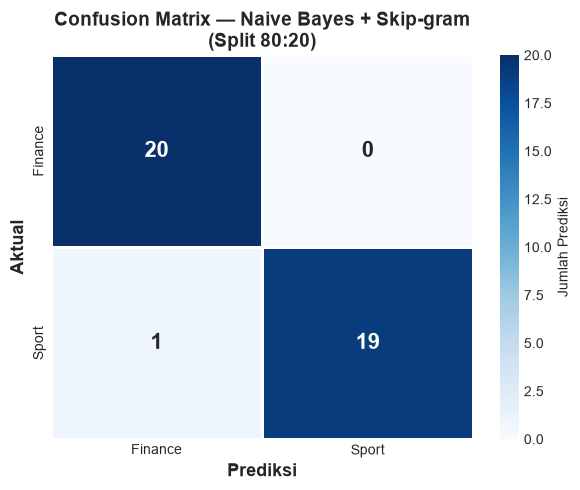

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Finance', 'Sport'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Finance', 'Sport'],
    yticklabels=['Finance', 'Sport'],
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Jumlah Prediksi'},
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)
ax.set_xlabel('Prediksi', fontsize=13, fontweight='bold')
ax.set_ylabel('Aktual', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix — Naive Bayes + Skip-gram\n(Split 80:20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Visualisasi: Proyeksi 2D Vektor Dokumen (PCA)

Reduksi dimensi menggunakan **PCA** (*Principal Component Analysis*) untuk memproyeksikan vektor dokumen berdimensi $N$ ke ruang 2D guna visualisasi separasi antar-kelas.

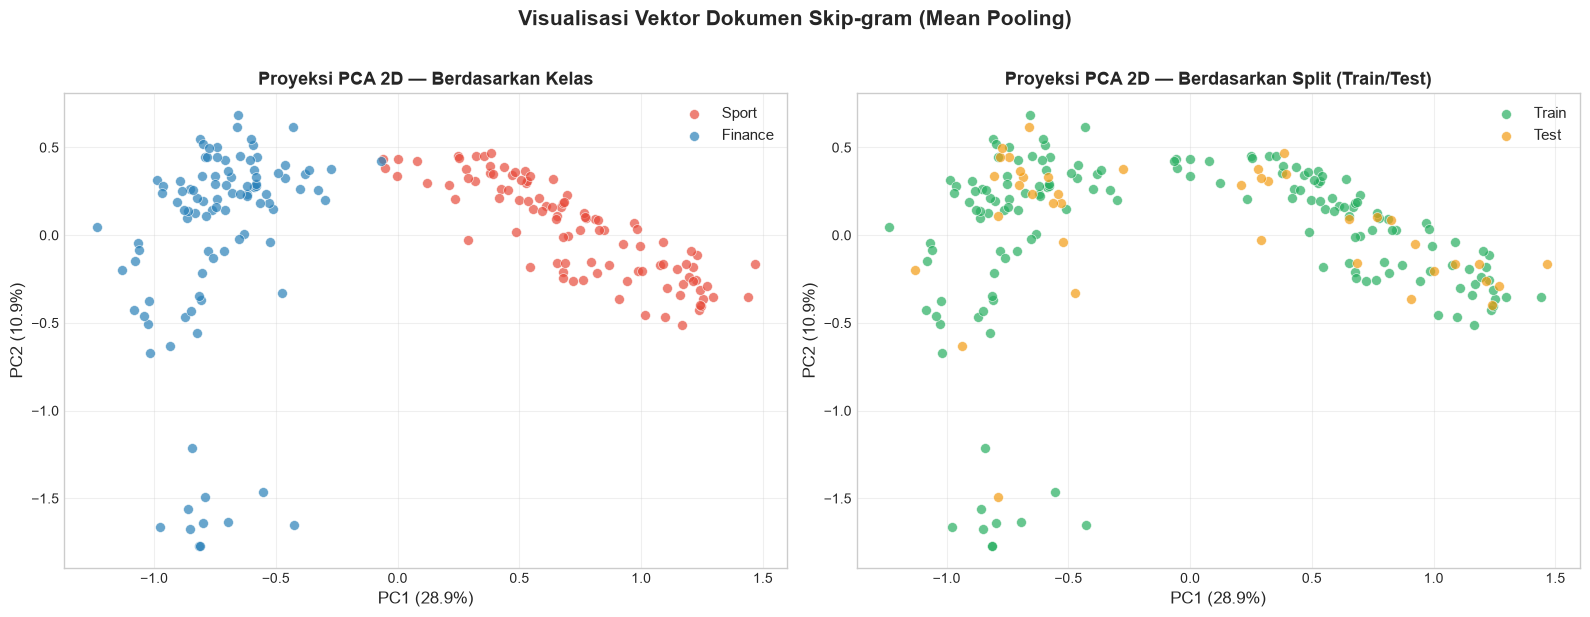

Explained variance ratio: PC1=0.2891, PC2=0.1088
Total variance explained : 39.79%


In [11]:
# Gabungkan seluruh data untuk visualisasi PCA
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
split_labels = ['Train'] * len(y_train) + ['Test'] * len(y_test)

# PCA: Reduksi ke 2 komponen
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Warna berdasarkan kelas (Sport vs Finance)
colors_class = {'Sport': '#e74c3c', 'Finance': '#2980b9'}
for label, color in colors_class.items():
    mask = np.array(y_all) == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('Proyeksi PCA 2D — Berdasarkan Kelas', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Warna berdasarkan split (Train vs Test)
colors_split = {'Train': '#27ae60', 'Test': '#f39c12'}
for split, color in colors_split.items():
    mask = np.array(split_labels) == split
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=split, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('Proyeksi PCA 2D — Berdasarkan Split (Train/Test)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Visualisasi Vektor Dokumen Skip-gram (Mean Pooling)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained : {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 10. Visualisasi: Distribusi Probabilitas Prediksi

=== PROBABILITAS PREDIKSI NAIVE BAYES (DATA UJI) ===


,ID,Label Aktual,P(Finance),P(Sport),Prediksi
0,138,Finance,1.000000e+00,0.000000e+00,Finance
1,41,Sport,9.452592e-36,1.000000e+00,Sport
2,96,Sport,1.671639e-17,1.000000e+00,Sport
3,97,Sport,6.362359e-22,1.000000e+00,Sport
4,124,Finance,1.000000e+00,2.996431e-33,Finance
5,5,Sport,9.178505e-43,1.000000e+00,Sport
6,130,Finance,1.000000e+00,0.000000e+00,Finance
7,81,Sport,9.999432e-01,5.682254e-05,Finance
8,62,Sport,1.080327e-35,1.000000e+00,Sport
9,187,Finance,1.000000e+00,7.656695e-41,Finance


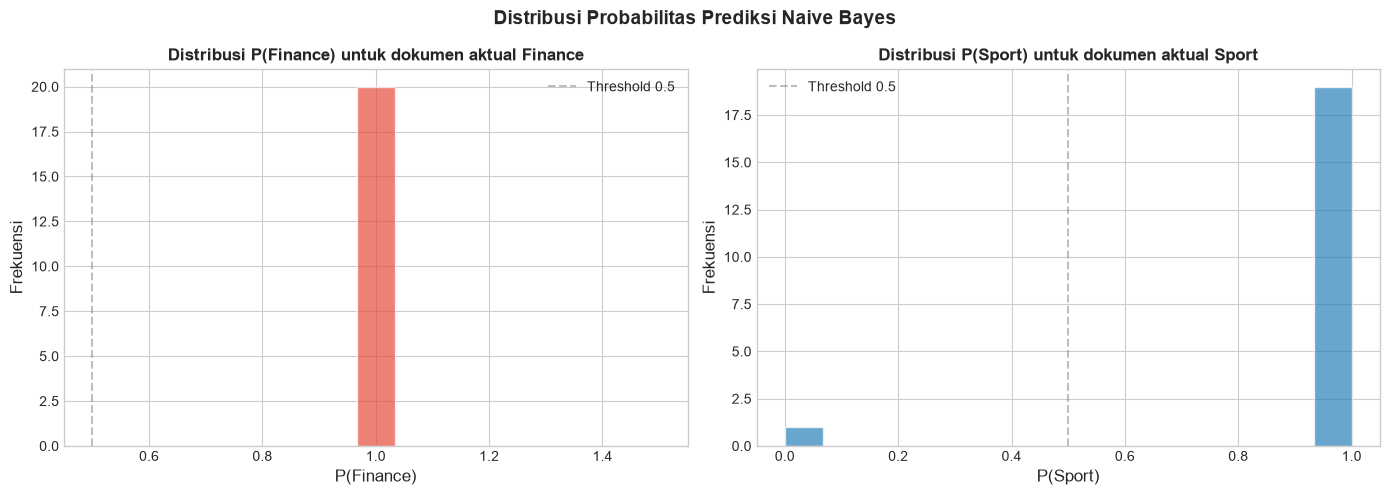

In [12]:
# Probabilitas prediksi Naive Bayes pada data uji
y_proba = nb_model.predict_proba(X_test)

df_proba = pd.DataFrame({
    'ID': df.loc[test_idx, 'ID'].values,
    'Label Aktual': y_test,
    'P(Finance)': y_proba[:, 0],
    'P(Sport)': y_proba[:, 1],
    'Prediksi': y_pred
})

print("=== PROBABILITAS PREDIKSI NAIVE BAYES (DATA UJI) ===")
display(df_proba)

# Histogram probabilitas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, kelas in enumerate(['Finance', 'Sport']):
    mask_actual = np.array(y_test) == kelas
    axes[i].hist(y_proba[mask_actual, i], bins=15, color=list(colors_class.values())[i],
                 alpha=0.7, edgecolor='white', linewidth=1)
    axes[i].set_xlabel(f'P({kelas})', fontsize=12)
    axes[i].set_ylabel('Frekuensi', fontsize=12)
    axes[i].set_title(f'Distribusi P({kelas}) untuk dokumen aktual {kelas}', fontsize=12, fontweight='bold')
    axes[i].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
    axes[i].legend()

plt.suptitle('Distribusi Probabilitas Prediksi Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Link Aplikasi Deteksi Berita

**https://utsppw-9znx4fmyon32pd8zyhezqd.streamlit.app/**